<a href="https://colab.research.google.com/github/Tanim353/fashion-cnn-210135/blob/main/210135_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
# Clone your repo (replace with your actual URL)
!git clone https://github.com/Tanim353/fashion-cnn-210135
%cd fashion-cnn-210135

Cloning into 'fashion-cnn-210135'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 19 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 33.69 KiB | 4.81 MiB/s, done.
/content/fashion-cnn-210114/fashion-cnn-210135/fashion-cnn-210135/fashion-cnn-210135/fashion-cnn-210135/fashion-cnn-210135/fashion-cnn-210135


In [104]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from PIL import Image
from sklearn.metrics import confusion_matrix
from tensorflow import keras


In [105]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(X_train.shape, y_train.shape)


(60000, 28, 28) (60000,)


In [106]:
X_train = X_train / 255.0
X_test  = X_test / 255.0

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)


In [107]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [108]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [109]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [110]:
epochs = 10

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(epochs):
    model.train()
    correct, total, loss_sum = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(loss_sum / len(train_loader))
    train_accs.append(correct / total)

    model.eval()
    correct, total, loss_sum = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_sum += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_losses.append(loss_sum / len(test_loader))
    test_accs.append(correct / total)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_accs[-1]:.4f} | Test Acc: {test_accs[-1]:.4f}")


Epoch 1/10 | Train Acc: 0.8141 | Test Acc: 0.8647
Epoch 2/10 | Train Acc: 0.8795 | Test Acc: 0.8868
Epoch 3/10 | Train Acc: 0.8976 | Test Acc: 0.8938
Epoch 4/10 | Train Acc: 0.9073 | Test Acc: 0.9007
Epoch 5/10 | Train Acc: 0.9164 | Test Acc: 0.9060
Epoch 6/10 | Train Acc: 0.9232 | Test Acc: 0.9107
Epoch 7/10 | Train Acc: 0.9312 | Test Acc: 0.9131
Epoch 8/10 | Train Acc: 0.9384 | Test Acc: 0.9118
Epoch 9/10 | Train Acc: 0.9437 | Test Acc: 0.9138
Epoch 10/10 | Train Acc: 0.9486 | Test Acc: 0.9180


In [111]:
os.makedirs("model", exist_ok=True)
torch.save(model.state_dict(), "model/190110.pth")


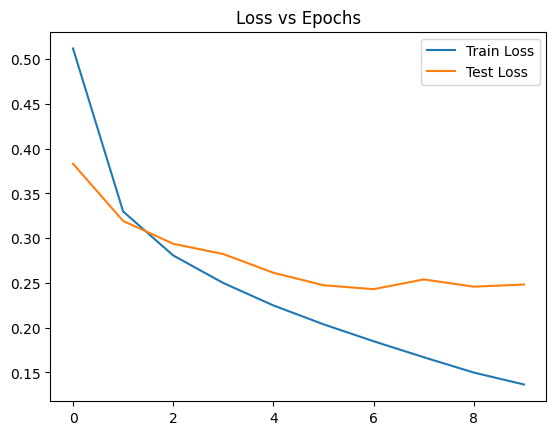

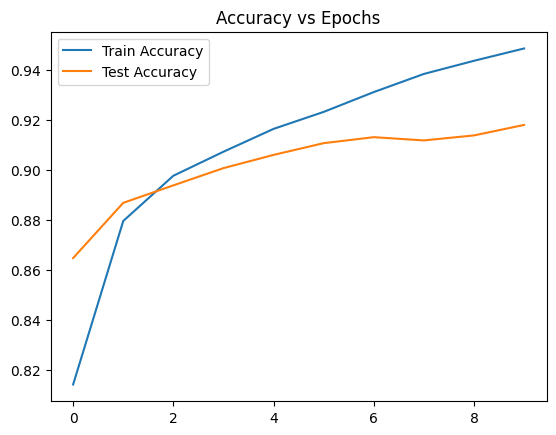

In [112]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()


In [113]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]


In [114]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [115]:
cm = confusion_matrix(all_labels, all_preds)


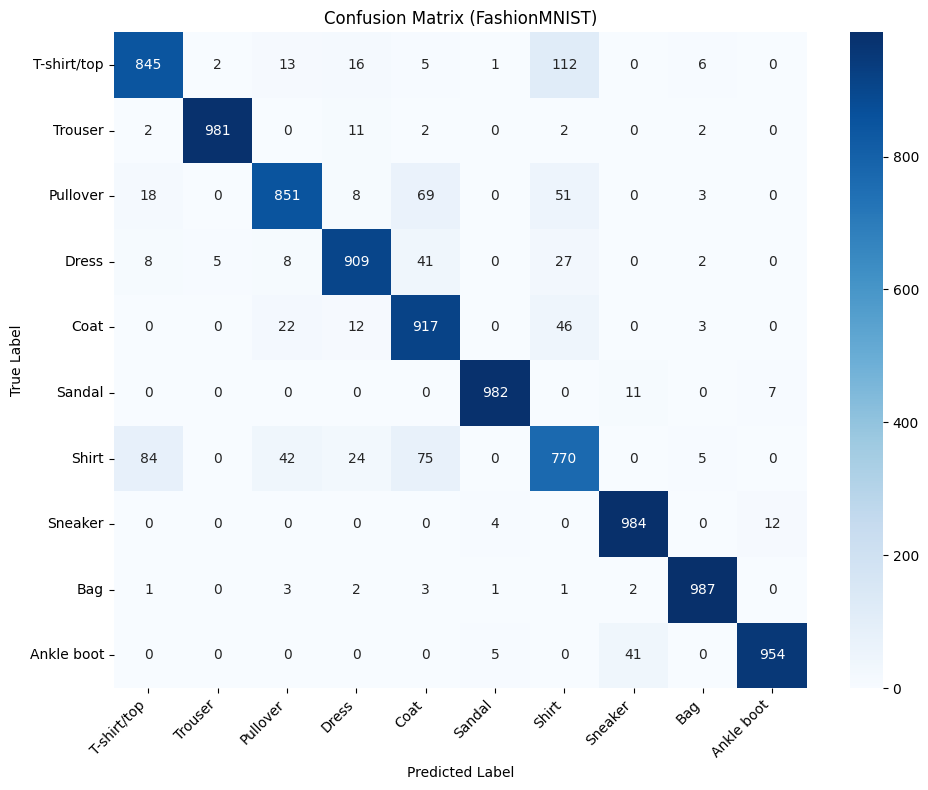

In [116]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (FashionMNIST)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [117]:
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

# Average loss and accuracy
test_loss /= len(test_loader)
test_acc = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")


Test Loss: 0.2482
Test Accuracy: 91.80%


In [118]:
from torchvision import transforms
preprocess = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(),
    transforms.ToTensor()
])

In [119]:
import requests
from io import BytesIO

In [120]:
api_url = "https://api.github.com/repos/Tanim353/fashion-cnn-210135/contents/dataset"
response = requests.get(api_url)

if response.status_code == 200:
    files = response.json()
else:
    print(f"Error fetching data from GitHub API: {response.status_code}")
    try:
        print(response.json()) # Attempt to print the error message from API if available
    except ValueError:
        print(response.text) # Print raw text if not JSON
    files = [] # Initialize files as empty list to prevent error in next cell

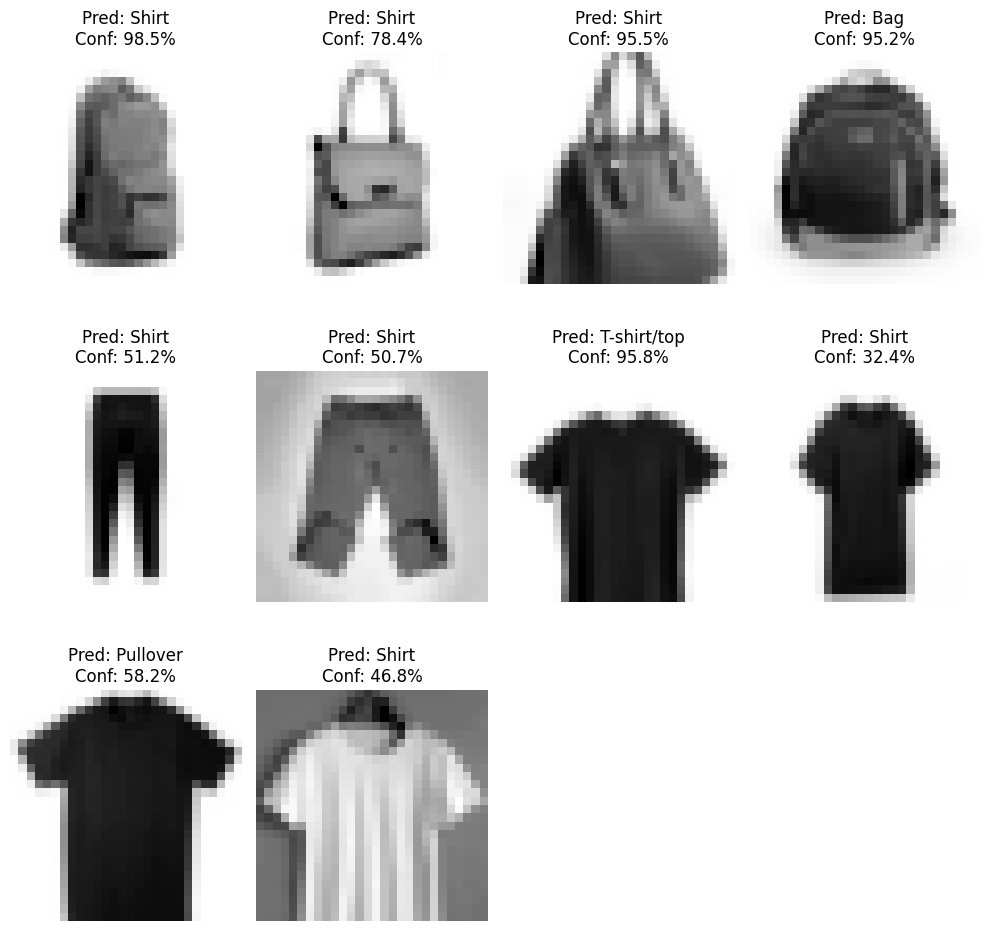

In [121]:
model.eval()
plt.figure(figsize=(10,10))

i = 0
for file in files:
    if file["type"] != "file":
        continue

    img_name = file["name"]
    if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    # RAW image URL
    img_url = file["download_url"]

    # Download image
    img = Image.open(BytesIO(requests.get(img_url).content)).convert("L")

    img_tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    plt.subplot(3,4,i+1)
    plt.imshow(img_tensor.squeeze().cpu(), cmap='gray')
    plt.title(f"Pred: {class_names[pred.item()]}\nConf: {conf.item()*100:.1f}%")
    plt.axis('off')

    i += 1
    if i == 12:
        break

plt.tight_layout()
plt.show()

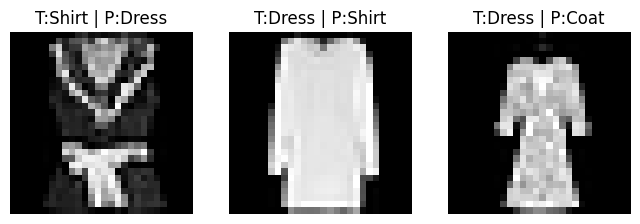

In [122]:
wrong = [(i, all_preds[i], all_labels[i])
         for i in range(len(all_preds)) if all_preds[i] != all_labels[i]]

sample = np.random.choice(len(wrong), 3, replace=False)

plt.figure(figsize=(8,4))
for idx, s in enumerate(sample):
    i, pred, true = wrong[s]
    img, _ = test_dataset[i]
    plt.subplot(1,3,idx+1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"T:{class_names[true]} | P:{class_names[pred]}")
    plt.axis("off")
plt.show()